# Emergency Services Analytics

## Project Goal

This project analyzes Montgomery County 911 emergency call data to identify trends in emergency service demand, uncover time-based patterns, and demonstrate practical data analysis techniques using Python.

Key questions include:

- What emergency types occur most frequently?
- When are emergency services busiest?
- How does call volume change throughout the week and year?
- What patterns can be observed in emergency activity?

In [65]:
import pandas as pd
import numpy as np
import datetime
%matplotlib inline

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
import plotly
import cufflinks as cf
cf.go_offline()

# Data Exploration

## Initial Dataset Inspection

Before performing any analysis, the dataset is inspected to understand its structure, identify potential data quality issues, and determine which features may be useful for analysis.

Key areas examined:

- Number of records
- Available features
- Data types
- Missing values

In [77]:
df = pd.read_csv('..\data\911.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  object 
 3   zip        86637 non-null  float64
 4   title      99492 non-null  object 
 5   timeStamp  99492 non-null  object 
 6   twp        99449 non-null  object 
 7   addr       98973 non-null  object 
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 6.8+ MB


# Feature Engineering

## Creating an Emergency Category

The `title` column contains both the emergency category and a description.

To simplify analysis, a new feature called `Reason` is created by extracting the emergency category from the title field.

This allows calls to be grouped into:

- EMS
- Fire
- Traffic


In [78]:
df.head(5)

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


# Emergency Call Distribution

## Analyzing Emergency Types

Understanding the distribution of emergency call categories provides insight into the types of incidents that place the greatest demand on emergency services.

The visualization below compares the frequency of:

- EMS calls
- Traffic incidents
- Fire-related emergencies


In [79]:
df['Reason'] = df['title'].apply(lambda title: title.split(':')[0])
import plotly.express as px

reason_counts = df['Reason'].value_counts().reset_index()
reason_counts.columns = ['Reason', 'Count']

fig = px.bar(reason_counts, x='Reason', y='Count', title='911 Calls by Reason', text='Count', color='Reason')

fig.show()

# Weekly Activity Analysis

## Calls by Day of Week

Emergency demand often varies throughout the week.

This analysis explores how call volume changes by day and examines differences between emergency categories.

Understanding these patterns can help identify periods of increased demand for emergency services.

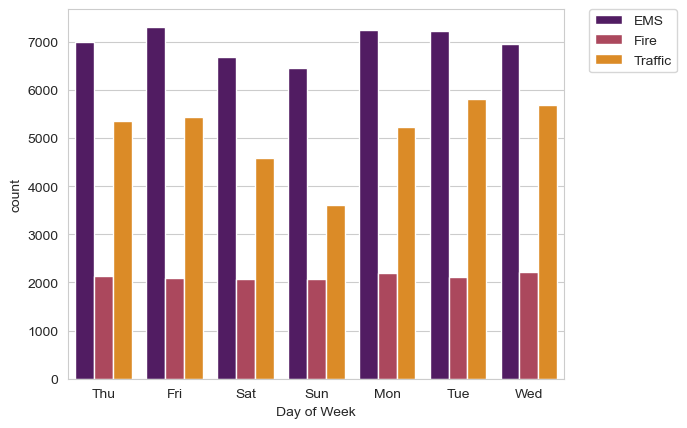

In [80]:
df['timeStamp'] = pd.to_datetime(df['timeStamp'])
df['Hour'] = df['timeStamp'].apply(lambda time: time.hour)
df['Month'] = df['timeStamp'].apply(lambda time: time.month)
df['Day of Week'] = df['timeStamp'].apply(lambda time: time.dayofweek)
dmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
df['Day of Week'] = df['Day of Week'].map(dmap)
sns.countplot(x='Day of Week',data=df,hue='Reason',palette='inferno')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# Monthly Trend Analysis

## Calls by Month

Monthly analysis helps identify seasonal patterns and changes in emergency activity throughout the year.

Understanding these trends can provide insight into how emergency service demand changes over time.

In [81]:
monthly_reason = pd.crosstab(df['Month'],df['Reason'])

fig = px.line(monthly_reason, title='Monthly 911 Calls by Reason', labels={'Month': 'Month', 'value': 'Number of Calls'})

fig.show()

# Trend Analysis

## Exploring Call Volume Trends

A regression plot is used to examine the relationship between month and total call volume.

While this analysis does not establish causation, it helps visualize overall trends and patterns in emergency activity throughout the year.

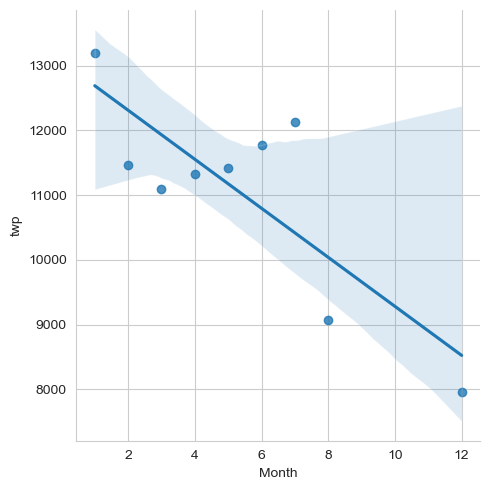

In [82]:
byMonth = df.groupby('Month').count()
sns.lmplot(x='Month',y='twp',data=byMonth.reset_index())

# Time-Series Analysis

## Daily Emergency Call Volume

Time-series analysis allows emergency activity to be observed over an extended period.

This visualization highlights:

- Peaks in demand
- Lower activity periods
- Overall trends in emergency service requests

Understanding daily fluctuations can provide valuable operational insights.

In [83]:
df['Date']=df['timeStamp'].apply(lambda t: t.date())


daily_calls = (df.groupby('Date').count()['twp'].reset_index())
daily_calls.columns = ['Date','Calls']

fig = px.line(daily_calls, x='Date', y='Calls', title='Daily 911 Calls')

fig.show()

# Township Analysis

## Geographic Distribution of Emergency Calls

Emergency call volume can vary significantly across townships.

This analysis examines which townships generate the highest number of emergency service requests and highlights areas with the greatest demand.

Understanding geographic patterns can support resource allocation and operational planning.

In [84]:
townships = (df['twp'].value_counts().head(10).reset_index())

townships.columns = ['twp','count']

fig = px.bar(townships, x='twp', y='count', title='Top 10 Townships by 911 Calls', text='count', color='twp')
fig.show()

# Heatmap Analysis

## Emergency Activity by Day and Hour

Heatmaps provide a visual representation of call activity across both days of the week and hours of the day.

This analysis helps identify:

- Peak activity periods
- Consistent demand patterns
- Time-based trends in emergency service requests

Darker regions indicate periods with higher call volume.

In [85]:
dayHour = df.groupby(by=['Day of Week','Hour']).count()['Reason'].unstack()

fig = px.imshow(dayHour, title='Heatmap of 911 Calls by Day and Hour', labels={'x': 'Hour of Day', 'y': 'Day of Week', 'color': 'Number of Calls'}, aspect='auto')
fig.show()

# Hourly Activity Analysis

## Calls by Hour of Day

Emergency activity often changes throughout the day.

This analysis investigates hourly call volume to identify peak periods and understand how demand fluctuates over a 24-hour cycle.

These insights can help illustrate when emergency services experience the highest workload.

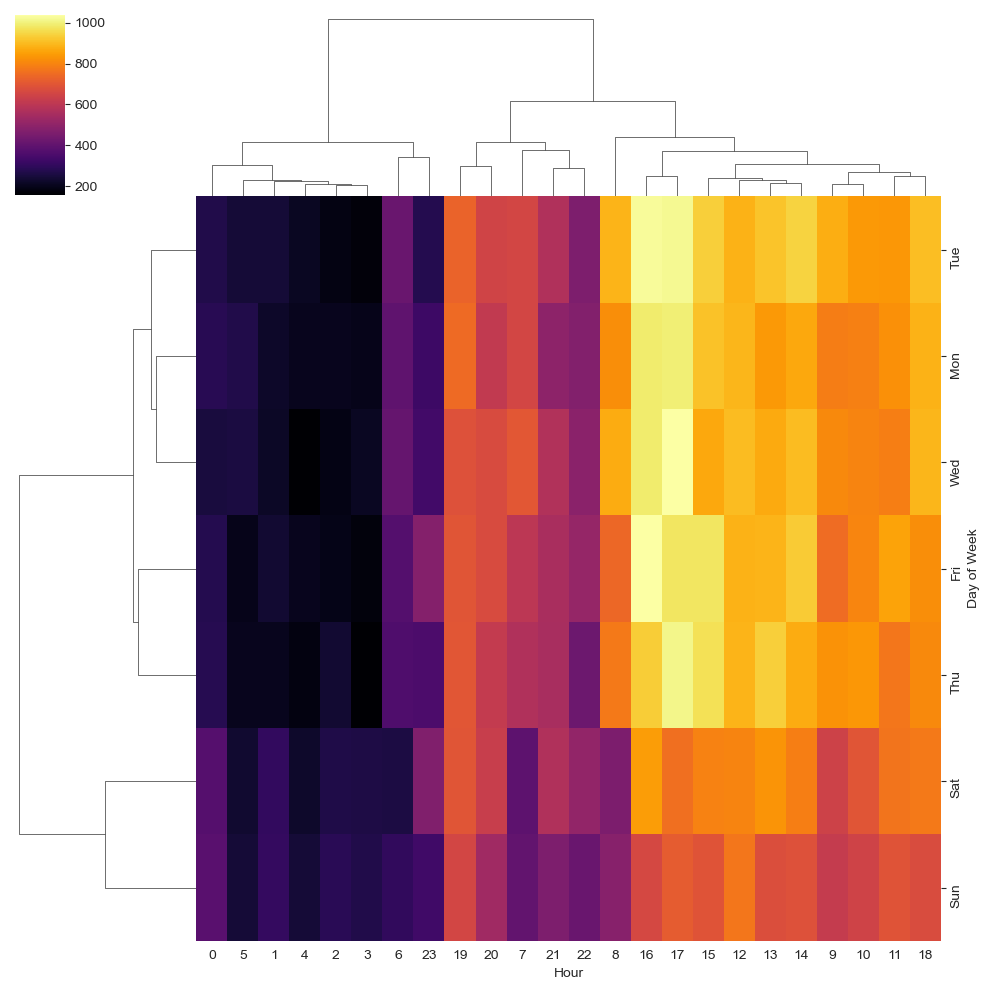

In [86]:
sns.clustermap(dayHour,cmap='inferno')

# Conclusion

## Summary of Findings

This analysis explored emergency service call data through data cleaning, feature engineering, exploratory data analysis, and visualization.

Key findings include:

- EMS calls represent the largest category of emergency requests.
- Emergency activity varies throughout the week and day.
- Certain hours consistently experience higher call volume.
- Monthly and daily trends reveal recurring patterns in emergency demand.
- Geographic analysis highlights areas with higher concentrations of emergency calls.

This project demonstrates the use of Python and data analysis techniques to extract meaningful insights from real-world data.